# Cahn-Hilliard loss visual check

This notebook loads the example predicted and true metadata, builds Cahn-Hilliard landscapes for two cell types first, visualizes the fields and energy densities, then computes the normalized exponential AUC loss for every cell type.

Note that the HYPERPARAMETERS HERE TESTED are GOOD FOR TRAINING

RADII =np.linspace(0.001, 0.01, 10)

GRID_RESOLUTION = 256

KAPPA = 0.5

SOFT_MAX_BETA = 32.0

SUPPORT_FACTOR = 64.0

MARGIN = 0.01

SQUARE_BBOX = True

EPS = 1e-6

MIN_CELLS_PER_TYPE = 10

In [11]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Make the notebook robust whether it is launched from the repo root or metrics/.
cwd = Path.cwd()
if (cwd / "example" / "example_result").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "example" / "example_result").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError(f"Could not find repo root from {cwd}")

METRICS_DIR = REPO_ROOT / "metrics"
for path in (REPO_ROOT, METRICS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from loss_function_plus import (  # noqa: E402
    build_continuous_landscape_from_points,
    cahn_hilliard_energy,
    cahn_hilliard_energy_density,
    shared_square_grid,
    sigmoid_bump,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")

Repo root: /home/asalmona/Documents/Ricci/code/Tissue-Reassembly-using-GenAI-and-new-metrics
Using device: cpu


## Load and align metadata

The two CSVs share the unnamed first column as the cell ID. We align prediction and ground truth by that ID before comparing positions.

In [12]:
pred_path = REPO_ROOT / "example" / "example_result" / "metadata_pred.csv"
true_path = REPO_ROOT / "example" / "example_result" / "metadata_true.csv"

pred_df = pd.read_csv(pred_path, index_col=0)
true_df = pd.read_csv(true_path, index_col=0)

required_columns = {"cell_class", "coord_X", "coord_Y"}
for name, df in {"pred": pred_df, "true": true_df}.items():
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{name} metadata is missing columns: {sorted(missing)}")

common_ids = true_df.index.intersection(pred_df.index)
if len(common_ids) == 0:
    raise ValueError("No shared cell IDs between true and predicted metadata.")

true_df = true_df.loc[common_ids].copy()
pred_df = pred_df.loc[common_ids].copy()

class_mismatch = (true_df["cell_class"].astype(str) != pred_df["cell_class"].astype(str)).sum()
print(f"Aligned cells: {len(common_ids)}")
print(f"Cell-class mismatches between files: {class_mismatch}")

display(true_df.head())
display(true_df["cell_class"].value_counts().rename("n_cells").to_frame())

Aligned cells: 3780
Cell-class mismatches between files: 0


,cell_class,coord_X,coord_Y
133277,Oligo,0.026848,0.116121
91841,Astro,0.052199,0.381970
55540,L6 CT,0.160931,0.067541
55257,L5 IT,0.063948,0.133388
103231,L5 ET,0.023917,0.035204


,n_cells
cell_class,
L4/5 IT,558
L2/3 IT,476
L6 CT,447
L5 IT,310
Oligo,298
Astro,296
Endo,253
L6 IT,193
L5 ET,163


## Parameters and helper functions

These values mirror the implementation in `loss_function_plus.py`. The loss compares the AUC of the Cahn-Hilliard energy curve across `RADII`.

In [13]:
# You can change these to match a training run.
RADII =np.linspace(0.001, 0.01, 10)
GRID_RESOLUTION = 256
KAPPA = 0.5
SOFT_MAX_BETA = 32.0
SUPPORT_FACTOR = 64.0
MARGIN = 0.01
SQUARE_BBOX = True
EPS = 1e-6
MIN_CELLS_PER_TYPE = 10

true_pos = torch.tensor(true_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
pred_pos = torch.tensor(pred_df[["coord_X", "coord_Y"]].to_numpy(), dtype=DTYPE, device=DEVICE)
cell_labels = true_df["cell_class"].astype(str)


def bump_kwargs_for_radius(radius):
    # This matches CahnHilliardEnergyAUCLoss._landscape in loss_function_plus.py.
    return {"decay_rate": 2 / radius, "shift": 128 * radius}


def type_mask_for(cell_type):
    return torch.tensor((cell_labels.values == cell_type), dtype=torch.bool, device=DEVICE)


def landscape_for_points(points, grid_x, grid_y, radius):
    valid_mask = torch.ones(points.shape[0], dtype=torch.bool, device=points.device)
    return build_continuous_landscape_from_points(
        points,
        valid_mask,
        grid_x,
        grid_y,
        radius=radius,
        bump_fn=sigmoid_bump,
        bump_kwargs=bump_kwargs_for_radius(radius),
        combine="soft_max",
        soft_max_beta=SOFT_MAX_BETA,
        support_factor=SUPPORT_FACTOR,
    )


def compute_type_curves(cell_type):
    mask = type_mask_for(cell_type)
    n_cells = int(mask.sum().item())
    if n_cells < MIN_CELLS_PER_TYPE:
        return None

    true_type = true_pos[mask]
    pred_type = pred_pos[mask]
    grid_x, grid_y, dx, dy = shared_square_grid(
        true_type,
        pred_type,
        grid_resolution=GRID_RESOLUTION,
        margin=MARGIN,
        square=SQUARE_BBOX,
    )

    e_true_curve = []
    e_pred_curve = []
    phi_by_radius = {}
    energy_density_by_radius = {}

    for radius in RADII:
        phi_true = landscape_for_points(true_type, grid_x, grid_y, radius)
        phi_pred = landscape_for_points(pred_type, grid_x, grid_y, radius)

        energy_density_true = cahn_hilliard_energy_density(phi_true, dx, dy, kappa=KAPPA)
        energy_density_pred = cahn_hilliard_energy_density(phi_pred, dx, dy, kappa=KAPPA)

        e_true_curve.append(energy_density_true.sum() * dx * dy)
        e_pred_curve.append(energy_density_pred.sum() * dx * dy)
        phi_by_radius[radius] = (phi_true, phi_pred)
        energy_density_by_radius[radius] = (energy_density_true, energy_density_pred)

    radii_t = torch.tensor(RADII, dtype=DTYPE, device=DEVICE)
    e_true_t = torch.stack(e_true_curve)
    e_pred_t = torch.stack(e_pred_curve)
    auc_true = torch.trapezoid(e_true_t, radii_t)
    auc_pred = torch.trapezoid(e_pred_t, radii_t)

    relative_auc_diff = (auc_pred - auc_true).abs() / (auc_true.detach().abs() + EPS)
    exp_normalized_loss = 1.0 - torch.exp(-relative_auc_diff)

    return {
        "cell_type": cell_type,
        "n_cells": n_cells,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "dx": dx,
        "dy": dy,
        "e_true_curve": e_true_t,
        "e_pred_curve": e_pred_t,
        "auc_true": auc_true,
        "auc_pred": auc_pred,
        "relative_auc_diff": relative_auc_diff,
        "loss_exp_normalized": exp_normalized_loss,
        "phi_by_radius": phi_by_radius,
        "energy_density_by_radius": energy_density_by_radius,
    }


def to_numpy(tensor):
    return tensor.detach().cpu().numpy()

## Pick two cell types and build landscapes

By default, this chooses the two most abundant cell types so the landscapes are easy to inspect. Change `selected_cell_types` manually if you want to inspect specific classes.

In [14]:
selected_cell_types = ['Endo', 'VLMC']
visual_radius = 0.01

with torch.no_grad():
    visual_results = {cell_type: compute_type_curves(cell_type) for cell_type in selected_cell_types}

print(f"Selected cell types: {selected_cell_types}")
print(f"Visual radius: {visual_radius}")

Selected cell types: ['Endo', 'VLMC']
Visual radius: 0.01


## Plot continuous landscapes

Each row is one cell type. Columns show the true landscape, predicted landscape, and their difference at `visual_radius`.

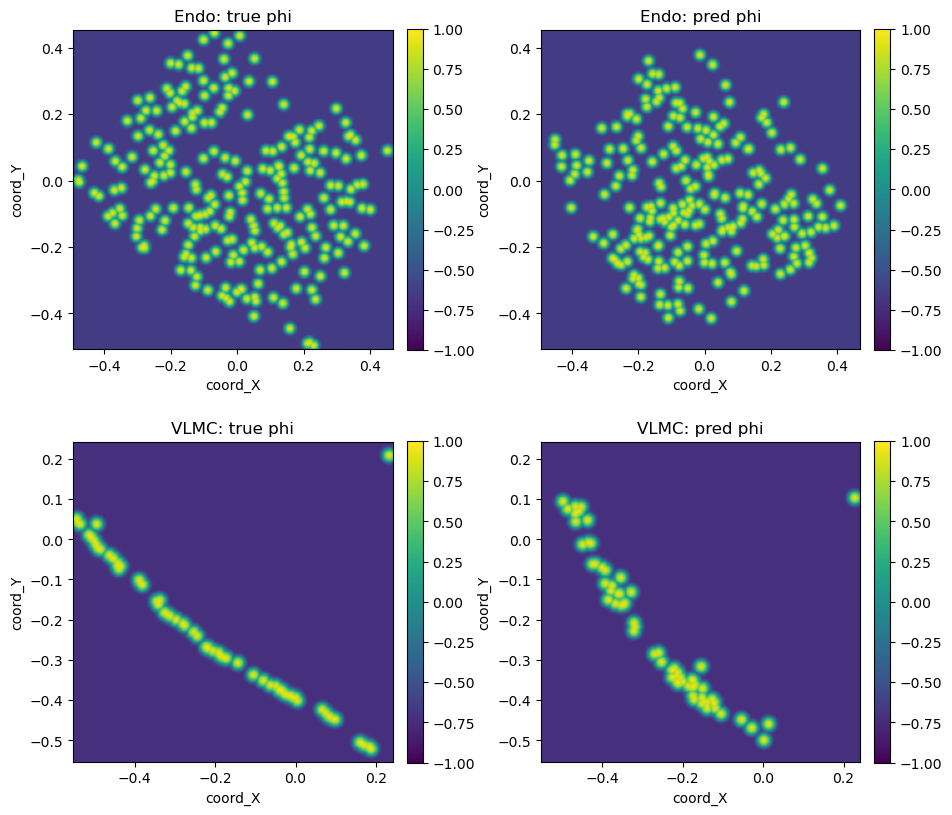

In [15]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    phi_true, phi_pred = result["phi_by_radius"][visual_radius]
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]

    panels = [
        (phi_true, "true phi", "viridis", -1.0, 1.0),
        (phi_pred, "pred phi", "viridis", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
   

plt.tight_layout()

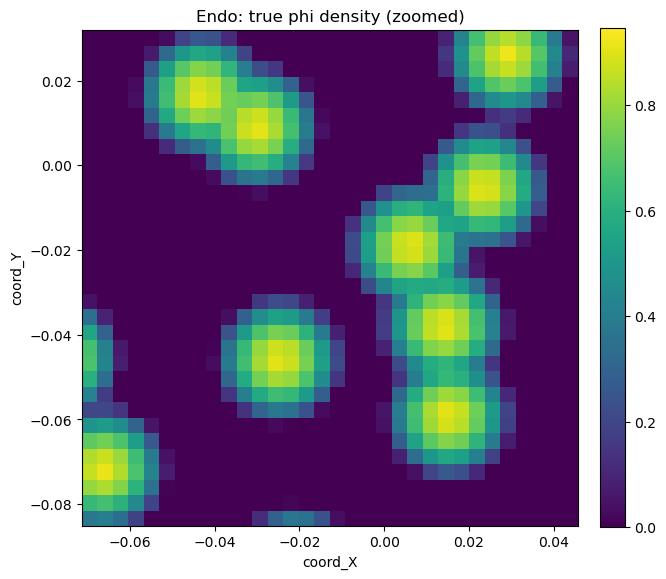

In [16]:
# Plot a zoomed-in view of the first "true energy density" panel for the first cell type

cell_type = selected_cell_types[0]
result = visual_results[cell_type]
e_true = result["phi_by_radius"][visual_radius][0]
grid_x = result["grid_x"]
grid_y = result["grid_y"]

# Choose zoom center and width/height: center and show a region that's 1/8 of the original area
h, w = e_true.shape
zoom_factor = 8
zh = h // (2 * zoom_factor)
zw = w // (2 * zoom_factor)
center_y = h // 2
center_x = w // 2
zoomed = e_true[center_y-zh:center_y+zh, center_x-zw:center_x+zw]

zoomed_extent = [
    float(grid_x[center_x-zw]),
    float(grid_x[center_x+zw-1]),
    float(grid_y[center_y-zh]),
    float(grid_y[center_y+zh-1]),
]

plt.figure(figsize=(7, 7))
plt.imshow(to_numpy(zoomed), origin="lower", extent=zoomed_extent, vmin=0.0, vmax=float(e_true.max().item()))
plt.title(f"{cell_type}: true phi density (zoomed)")
plt.xlabel("coord_X")
plt.ylabel("coord_Y")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## Plot Cahn-Hilliard energy densities

These are the per-grid-cell energy densities `(phi^2 - 1)^2 + kappa * |grad phi|^2` for the same two cell types and radius.

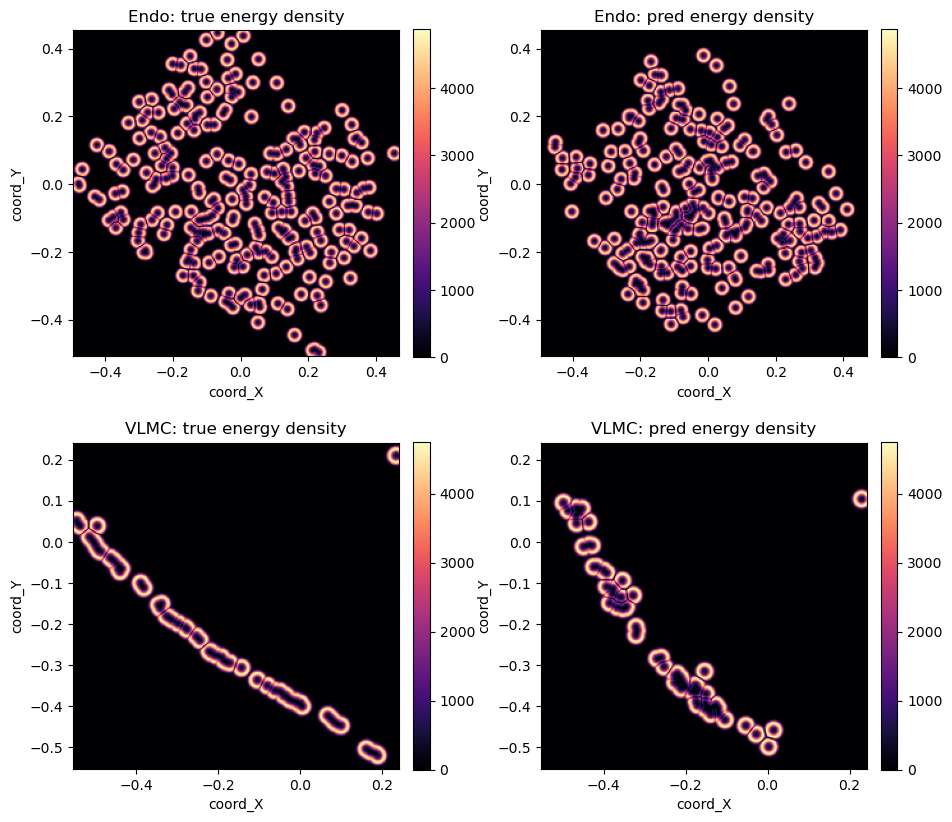

In [17]:
fig, axes = plt.subplots(len(selected_cell_types), 2, figsize=(9.5, 4.2 * len(selected_cell_types)), squeeze=False)

for row, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    e_true, e_pred = result["energy_density_by_radius"][visual_radius]
    diff = e_pred - e_true
    grid_x = result["grid_x"]
    grid_y = result["grid_y"]
    extent = [grid_x.min().item(), grid_x.max().item(), grid_y.min().item(), grid_y.max().item()]
    shared_vmax = max(float(e_true.max().item()), float(e_pred.max().item()))

    panels = [
        (e_true, "true energy density", "magma", 0.0, shared_vmax),
        (e_pred, "pred energy density", "magma", 0.0, shared_vmax),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(to_numpy(image), origin="lower", extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"{cell_type}: {title}")
        ax.set_xlabel("coord_X")
        ax.set_ylabel("coord_Y")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

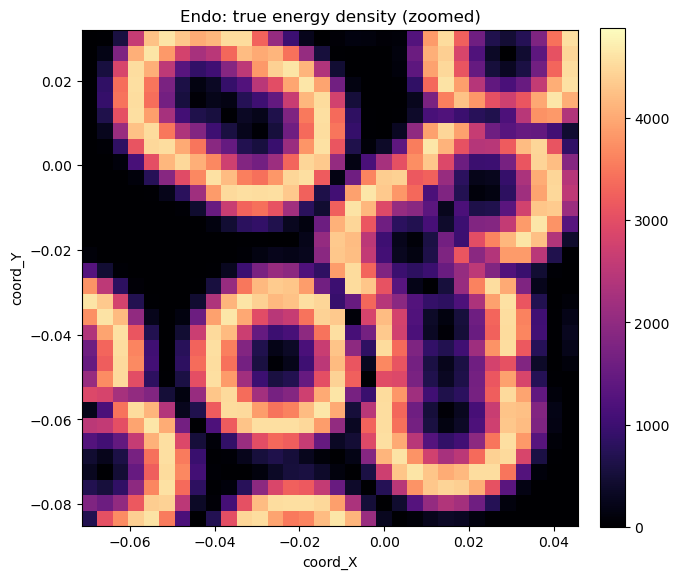

In [18]:
# Plot a zoomed-in view of the first "true energy density" panel for the first cell type

cell_type = selected_cell_types[0]
result = visual_results[cell_type]
e_true = result["energy_density_by_radius"][visual_radius][0]
grid_x = result["grid_x"]
grid_y = result["grid_y"]

# Choose zoom center and width/height: center and show a region that's 1/8 of the original area
h, w = e_true.shape
zoom_factor = 8
zh = h // (2 * zoom_factor)
zw = w // (2 * zoom_factor)
center_y = h // 2
center_x = w // 2
zoomed = e_true[center_y-zh:center_y+zh, center_x-zw:center_x+zw]

zoomed_extent = [
    float(grid_x[center_x-zw]),
    float(grid_x[center_x+zw-1]),
    float(grid_y[center_y-zh]),
    float(grid_y[center_y+zh-1]),
]

plt.figure(figsize=(7, 7))
plt.imshow(to_numpy(zoomed), origin="lower", extent=zoomed_extent, cmap="magma", vmin=0.0, vmax=float(e_true.max().item()))
plt.title(f"{cell_type}: true energy density (zoomed)")
plt.xlabel("coord_X")
plt.ylabel("coord_Y")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

## Plot energy curves for the two visualized cell types

The final loss compares the trapezoidal AUCs of these curves.

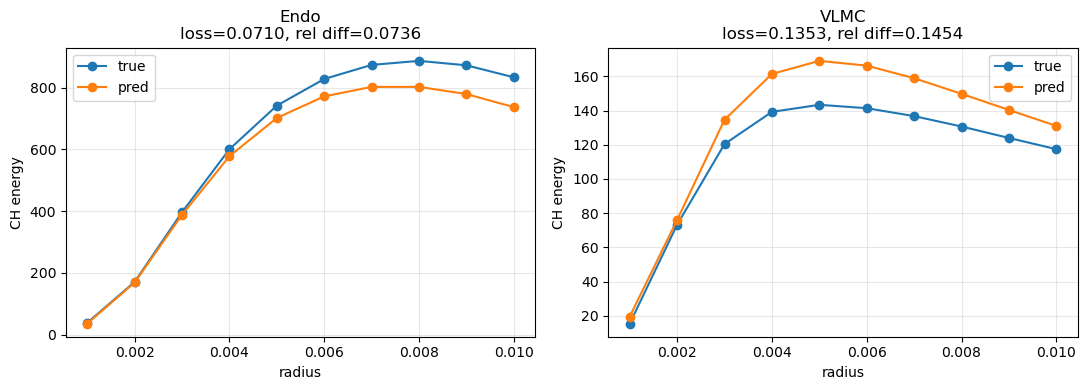

In [19]:
fig, axes = plt.subplots(1, len(selected_cell_types), figsize=(5.5 * len(selected_cell_types), 4), squeeze=False)

for col, cell_type in enumerate(selected_cell_types):
    result = visual_results[cell_type]
    ax = axes[0, col]
    ax.plot(RADII, to_numpy(result["e_true_curve"]), marker="o", label="true")
    ax.plot(RADII, to_numpy(result["e_pred_curve"]), marker="o", label="pred")
    ax.set_title(
        f"{cell_type}\n"
        f"loss={result['loss_exp_normalized'].item():.4f}, "
        f"rel diff={result['relative_auc_diff'].item():.4f}"
    )
    ax.set_xlabel("radius")
    ax.set_ylabel("CH energy")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

## Compute the loss for every cell type

For each cell type, this computes:

`relative_auc_diff = abs(AUC_pred - AUC_true) / (abs(AUC_true) + EPS)`

`loss_exp_normalized = 1 - exp(-relative_auc_diff)`

In [20]:
all_results = []

with torch.no_grad():
    for cell_type in cell_labels.value_counts().index:
        result = compute_type_curves(cell_type)
        if result is None:
            continue
        all_results.append(
            {
                "cell_type": cell_type,
                "n_cells": result["n_cells"],
                "auc_true": result["auc_true"].item(),
                "auc_pred": result["auc_pred"].item(),
                "relative_auc_diff": result["relative_auc_diff"].item(),
                "loss_exp_normalized": result["loss_exp_normalized"].item(),
            }
        )

loss_df = pd.DataFrame(all_results).sort_values("loss_exp_normalized", ascending=False)
display(loss_df)

,cell_type,n_cells,auc_true,auc_pred,relative_auc_diff,loss_exp_normalized
17,SMC,48,0.983898,1.419706,0.442940,0.357855
16,L6b,54,1.021569,1.287379,0.260197,0.229100
13,PVM,79,1.697198,2.128142,0.253915,0.224243
14,VLMC,71,1.075374,1.231680,0.145351,0.135281
3,L5 IT,310,5.138550,4.641041,0.096819,0.092280
5,Astro,296,6.506806,5.963408,0.083512,0.080120
12,OPC,81,2.099332,2.267185,0.079956,0.076843
6,Endo,253,5.806274,5.378949,0.073597,0.070954
11,Micro,93,2.624117,2.442521,0.069203,0.066863
4,Oligo,298,4.975543,4.674555,0.060494,0.058700


## Plot normalized exponential loss for all cell types

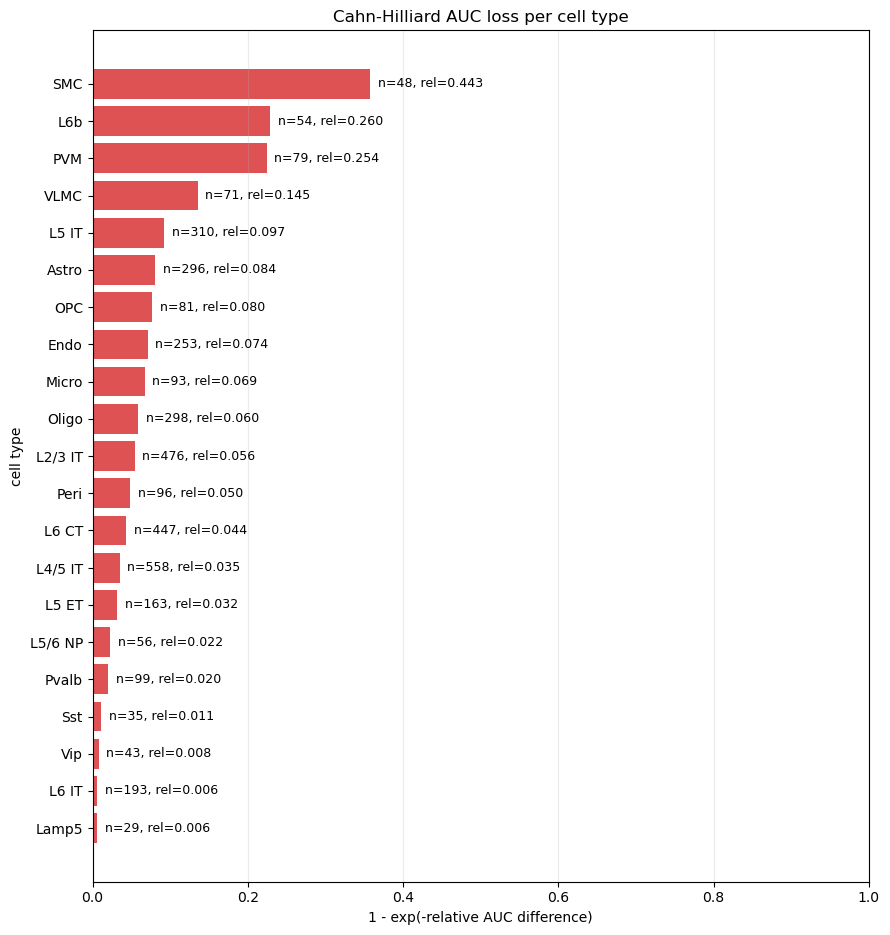

In [21]:
plot_df = loss_df.sort_values("loss_exp_normalized", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
ax.barh(plot_df["cell_type"], plot_df["loss_exp_normalized"], color="tab:red", alpha=0.8)
ax.set_xlabel("1 - exp(-relative AUC difference)")
ax.set_ylabel("cell type")
ax.set_title("Cahn-Hilliard AUC loss per cell type")
ax.set_xlim(0, max(1.0, float(plot_df["loss_exp_normalized"].max()) * 1.05))
ax.grid(axis="x", alpha=0.25)

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["loss_exp_normalized"] + 0.01,
        i,
        f"n={int(row['n_cells'])}, rel={row['relative_auc_diff']:.3f}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()

## Compute the combined loss

This calls `CombinedLossFunction` from `loss_function_plus.py` on the whole slice with original pairwise-distance MSE weight `1.0` and Cahn-Hilliard weight `1e-3`.

## Compute pairwise-distance MSE on the whole slice

This uses `LossFunction` from `loss_function.py`, which compares the full pairwise distance matrices between the true and predicted positions.

In [25]:
import sys
sys.path.insert(0, str(REPO_ROOT))
from loss_function import LossFunction as PairwiseDistanceMSELossFunction  # noqa: E402
from utils.data.dataholder import DataHolder

def make_position_dataholder(df: pd.DataFrame) -> DataHolder:
    positions = torch.as_tensor(
        df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)
    node_features = torch.zeros((1, positions.shape[1], 1), device=DEVICE, dtype=DTYPE)
    node_mask = torch.ones((1, positions.shape[1]), device=DEVICE, dtype=torch.bool)
    return DataHolder(
        positions=positions,
        node_features=node_features,
        diffusion_time=None,
        node_mask=node_mask,
    )


true_holder = make_position_dataholder(true_df)
pred_holder = make_position_dataholder(pred_df)
pairwise_mse_loss_fn = PairwiseDistanceMSELossFunction().to(DEVICE)

with torch.no_grad():
    pairwise_mse_loss, _ = pairwise_mse_loss_fn(
        masked_pred=pred_holder,
        masked_true=true_holder,
        train_stage=False,
        log=False,
    )

n_cells = int(true_holder.node_mask.sum().item())
n_pairwise_entries = n_cells * n_cells
print(f"Cells in whole slice: {n_cells:,}")
print(f"Pairwise distance entries compared: {n_pairwise_entries:,}")
print(f"Pairwise-distance MSE loss from loss_function.py: {pairwise_mse_loss.item():.6g}")

if "loss_df" in globals() and len(loss_df) > 0:
    weighted_ch_loss = np.average(loss_df["loss_exp_normalized"], weights=np.log(loss_df["n_cells"]))
    print(
        "Cahn-Hilliard normalized loss across cell types: "
        f"mean={loss_df['loss_exp_normalized'].mean():.6g}, "
        f"weighted_mean={weighted_ch_loss:.6g}, "
        f"max={loss_df['loss_exp_normalized'].max():.6g},"
        f"total_loss={loss_df['loss_exp_normalized'].sum()}"
    )

Cells in whole slice: 3,780
Pairwise distance entries compared: 14,288,400
Pairwise-distance MSE loss from loss_function.py: 0.0362132
Cahn-Hilliard normalized loss across cell types: mean=0.0798658, weighted_mean=0.0764036, max=0.357855,total_loss=1.6771818399429321


In [27]:
from loss_function_plus import CombinedLossFunction  # noqa: E402


def make_combined_loss_dataholders(
    pred_df: pd.DataFrame,
    true_df: pd.DataFrame,
) -> tuple[DataHolder, DataHolder, dict[int, str]]:
    pred_positions = torch.as_tensor(
        pred_df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)
    true_positions = torch.as_tensor(
        true_df[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32),
        device=DEVICE,
        dtype=DTYPE,
    ).unsqueeze(0)

    class_categories = pd.Categorical(true_df["cell_class"].astype(str))
    cell_class = torch.as_tensor(
        class_categories.codes,
        device=DEVICE,
        dtype=torch.long,
    ).unsqueeze(0)
    class_id_to_name = dict(enumerate(class_categories.categories.astype(str)))

    n_cells = true_positions.shape[1]
    node_features = torch.zeros((1, n_cells, 1), device=DEVICE, dtype=DTYPE)
    node_mask = torch.ones((1, n_cells), device=DEVICE, dtype=torch.bool)

    pred_holder = DataHolder(
        positions=pred_positions,
        node_features=node_features.clone(),
        diffusion_time=None,
        node_mask=node_mask,
    )
    true_holder = DataHolder(
        positions=true_positions,
        node_features=node_features,
        diffusion_time=None,
        cell_class=cell_class,
        node_mask=node_mask,
    )
    return pred_holder, true_holder, class_id_to_name


combined_pred_holder, combined_true_holder, class_id_to_name = make_combined_loss_dataholders(
    pred_df,
    true_df,
)

combined_loss_fn = CombinedLossFunction(
    mse_weight=1.0,
    ch_weight=1e-3,
    radii=RADII,
    grid_resolution=GRID_RESOLUTION,
    kappa=KAPPA,
    soft_max_beta=SOFT_MAX_BETA,
    support_factor=SUPPORT_FACTOR,
    square_bbox=SQUARE_BBOX,
    margin=MARGIN,
    eps=EPS,
    min_cells_per_type=MIN_CELLS_PER_TYPE,
).to(DEVICE)

with torch.no_grad():
    mse_component, _ = combined_loss_fn.mse_loss(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )
    ch_component, _ = combined_loss_fn.ch_loss(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )
    combined_loss, _ = combined_loss_fn(
        combined_pred_holder,
        combined_true_holder,
        train_stage=False,
        log=False,
    )

print(f"Cells in whole slice: {int(combined_true_holder.node_mask.sum().item()):,}")
print(f"Cell types included: {len(class_id_to_name)}")
print(f"Original pairwise-distance MSE component: {mse_component.item():.6g}")
print(f"Cahn-Hilliard component before weighting: {ch_component.item():.6g}")
print(f"Weighted Cahn-Hilliard contribution (1e-3 * CH): {(1e-3 * ch_component).item():.6g}")
print(f"Total combined loss: {combined_loss.item():.6g}")

/tmp/ipykernel_252463/2488884214.py:20: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  cell_class = torch.as_tensor(


Cells in whole slice: 3,780
Cell types included: 22
Original pairwise-distance MSE component: 0.0362132
Cahn-Hilliard component before weighting: 1.50454
Weighted Cahn-Hilliard contribution (1e-3 * CH): 0.00150454
Total combined loss: 0.0377177
